<a href="https://colab.research.google.com/github/CMILINAZZO/medical-llm-self-bias-audit/blob/main/notebooks/04_analysis_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import os
import shutil
from pathlib import Path
import pandas as pd
from google.colab import userdata

# 1. Configuration
GITHUB_USERNAME = "CMILINAZZO"
REPO_NAME = "medical-llm-self-bias-audit"
REPO_ROOT = Path(f"/content/{REPO_NAME}")

# 2. Clean clone sequence
if REPO_ROOT.exists() and not (REPO_ROOT / ".git").exists():
    shutil.rmtree(REPO_ROOT)

if not REPO_ROOT.exists():
    print("Cloning fresh copy of the repository...")
    !git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
else:
    print("Repository found. Pulling latest updates...")
    os.chdir(REPO_ROOT)
    !git pull

# 3. Synchronize Working Directory
os.chdir(REPO_ROOT / "notebooks")
print(f"\\n Active Working Directory synchronized to: {os.getcwd()}")

Cloning fresh copy of the repository...
Cloning into 'medical-llm-self-bias-audit'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 176 (delta 114), reused 9 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 659.45 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (114/114), done.
\n Active Working Directory synchronized to: /content/medical-llm-self-bias-audit/notebooks


In [2]:
# Cell 2: Load & Clean the Data

# 1. Define standard paths
OUTPUT_PATH = "../outputs/final_audit_matrix.csv"

# 2. Load the matrix
df_audit = pd.read_csv(OUTPUT_PATH)

# 3. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_audit['judge_model'] = df_audit['judge_model'].apply(clean_judge_name)

print(f" Data loaded and cleaned! Total evaluations: {len(df_audit)}")
print("\\nJudge Distribution:")
print(df_audit['judge_model'].value_counts())

 Data loaded and cleaned! Total evaluations: 507
\nJudge Distribution:
judge_model
gpt-4o               250
claude-sonnet-4-6    170
gemini-2.5-pro        87
Name: count, dtype: int64


**IMPORTANT NOTE:** The following Cell 3 only needs to be run if you had to run cells 7-8 in Notebook 3.

In [4]:
# Cell 3: Load & Clean the Data

# 1. Load both files
df_salvaged = pd.read_csv('../outputs/salvaged_audit_matrix.csv')
df_final = pd.read_csv('../outputs/final_audit_matrix.csv')

# 2. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_salvaged['judge_model'] = df_salvaged['judge_model'].apply(clean_judge_name)
df_final['judge_model'] = df_final['judge_model'].apply(clean_judge_name)

# 3. Combine, prioritize the final matrix (since it has ROUGE-L), and drop duplicates
df_combined = pd.concat([df_final, df_salvaged], ignore_index=True)
df_master = df_combined.drop_duplicates(subset=['pmid', 'student_model', 'judge_model'], keep='first')

print(f"Yay! Total unique evaluations squeezed out: {len(df_master)}")
print("\nFinal Judge Distribution:")
print(df_master['judge_model'].value_counts())

Yay! Total unique evaluations squeezed out: 571

Final Judge Distribution:
judge_model
gpt-4o               299
claude-sonnet-4-6    170
gemini-2.5-pro       102
Name: count, dtype: int64


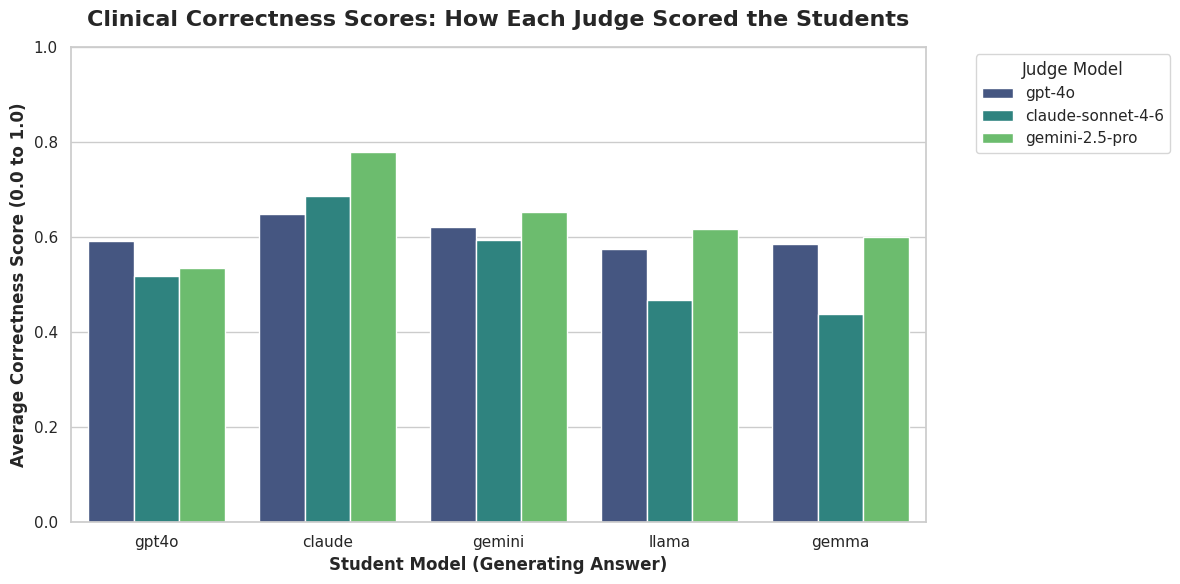

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 4: Correctness by Judge - Grouped Bar Chart

# Set the visual style for the charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a grouped bar chart
ax = sns.barplot(
    data=df_master,
    x='student_model',
    y='correctness_score',
    hue='judge_model',
    palette='viridis',
    errorbar=None # Turns off the confidence interval lines for a cleaner look
)

# Formatting the chart
plt.title('Clinical Correctness Scores: How Each Judge Scored the Students', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Student Model (Generating Answer)', fontsize=12, fontweight='bold')
plt.ylabel('Average Correctness Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0) # Lock the y-axis to a 0-1 scale
plt.legend(title='Judge Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the chart
plt.show()

**Observations on Correctness:**  
* claude as a judge:
  * Very punitive towards the local models (gemma & llama)
  * Prefers its own responses above the others, but maybe not unjustly - all judges rated claude the highest
* gemini as a judge:
  * Most lenient judge overall, *except* with gpt4o
  * Prefers its own responses to a degree, but it's unclear if this is self bias, or just a more positive rating tendency overall
* gpt4o as a judge:
  * Rating averages are all just below or just above 0.6

Claude performed the best, according to all 3 judges. The judges were most aligned on Gemini's performance.

In [6]:
# Cell 4: Neatly Formatted Score Averages Table
import pandas as pd

# 1. Calculate average Correctness scores by Student and Judge
pivot_correctness = df_master.pivot_table(
    index='student_model',
    columns='judge_model',
    values='correctness_score',
    aggfunc='mean'
)

# 2. Calculate average Faithfulness scores by Student and Judge
pivot_faithfulness = df_master.pivot_table(
    index='student_model',
    columns='judge_model',
    values='faithfulness_score',
    aggfunc='mean'
)

# 3. Rename columns for clean presentation
column_mapping = {
    'claude-sonnet-4-6': 'Claude Judge (Avg)',
    'gemini-2.5-pro': 'Gemini Judge (Avg)',
    'gpt-4o': 'GPT-4o Judge (Avg)'
}

pivot_correctness = pivot_correctness.rename(columns=column_mapping)
pivot_faithfulness = pivot_faithfulness.rename(columns=column_mapping)

# 4. Display the Correctness Matrix with formatting
print("="*60)
print("             CLINICAL CORRECTNESS MATRIX")
print("="*60)
display(pivot_correctness.style.format("{:.3f}").background_gradient(cmap='Blues', axis=None))

print("\n" + "="*60)
print("             FACTUAL FAITHFULNESS MATRIX")
print("="*60)
display(pivot_faithfulness.style.format("{:.3f}").background_gradient(cmap='Greens', axis=None))

             CLINICAL CORRECTNESS MATRIX


judge_model,Claude Judge (Avg),Gemini Judge (Avg),GPT-4o Judge (Avg)
student_model,,,
claude,0.685,0.779,0.647
gemini,0.594,0.653,0.621
gemma,0.438,0.600,0.584
gpt4o,0.518,0.535,0.592
llama,0.468,0.617,0.574



             FACTUAL FAITHFULNESS MATRIX


judge_model,Claude Judge (Avg),Gemini Judge (Avg),GPT-4o Judge (Avg)
student_model,,,
claude,0.973,0.994,0.957
gemini,0.969,0.986,0.948
gemma,0.910,0.873,0.898
gpt4o,0.969,0.974,0.961
llama,0.962,0.948,0.937


At this point, it is worth noting that when you have missing observations across different groups (in this case, GPT-4o graded 50 questions, Claude graded ~34, and Gemini graded ~20), directly comparing their overall averages introduces Row-Level Difficulty. To eliminate this confounding variable, we will use an Intersection Analysis (or Paired/Repeated Measures Framework). We filter the dataset down to only the specific rows (PMIDs) that were successfully graded by all three judges.

INTERSECTION ANALYSIS (28 Common Clinical Questions)


judge_model,claude-sonnet-4-6,gemini-2.5-pro,gpt-4o
student_model,,,
claude,0.643,0.788,0.641
gemini,0.596,0.707,0.625
gemma,0.454,0.650,0.582
gpt4o,0.518,0.547,0.576
llama,0.461,0.567,0.558


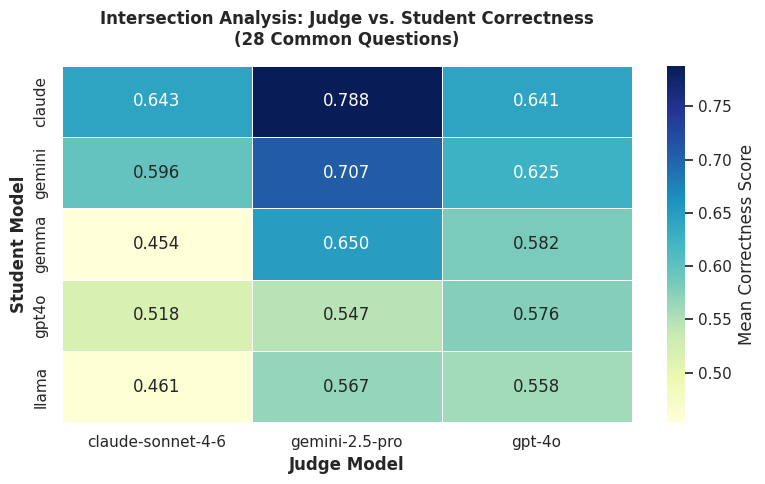

In [11]:
import pandas as pd

# 1. Load both files from the outputs directory
df_salvaged = pd.read_csv('../outputs/salvaged_audit_matrix.csv')
df_final = pd.read_csv('../outputs/final_audit_matrix.csv')

# 2. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_salvaged['judge_model'] = df_salvaged['judge_model'].apply(clean_judge_name)
df_final['judge_model'] = df_final['judge_model'].apply(clean_judge_name)

# 3. Combine, prioritize the final matrix (since it has ROUGE-L), and drop duplicates
df_combined = pd.concat([df_final, df_salvaged], ignore_index=True)
df_master = df_combined.drop_duplicates(subset=['pmid', 'student_model', 'judge_model'], keep='first')

# 4. Filter down to the intersection (PMIDs evaluated by ALL THREE judges)
pmid_judge_counts = df_master.groupby('pmid')['judge_model'].nunique()
common_pmids = pmid_judge_counts[pmid_judge_counts == 3].index.tolist()

df_intersection = df_master[df_master['pmid'].isin(common_pmids)]

# 5. Build the perfectly balanced Pivot Table
pivot_intersection = df_intersection.pivot_table(
    index='student_model',
    columns='judge_model',
    values='correctness_score',
    aggfunc='mean'
)

print("="*60)
print(f"INTERSECTION ANALYSIS ({len(common_pmids)} Common Clinical Questions)")
print("="*60)

# Render a clean HTML table instead of plain text
display(pivot_intersection.style.format("{:.3f}").background_gradient(cmap='Blues', axis=1))

# 6. Generate the Heatmap Visualization
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_intersection,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Mean Correctness Score'},
    linewidths=0.5
)

plt.title(f"Intersection Analysis: Judge vs. Student Correctness\n({len(common_pmids)} Common Questions)", pad=15, fontweight='bold')
plt.ylabel("Student Model", fontweight='bold')
plt.xlabel("Judge Model", fontweight='bold')
plt.tight_layout()

# Show the chart
plt.show()

We're still seeing some of the same trends, even when we're only looking at the 28 common questions.

* Claude is very punitive towards the local models.
* Gemini is the most lenient judge, *except* with gpt4o.
* Gemini prefers its responses over all except Claude.
* All 3 models preferred their own responses.

There are also some interesting differences.

* There seems to be more variance in gpt4o's grading.
* Gemini and gpt4o agree on ranking (but not score), best to worst is claude -> gemini -> gemma -> gpt4o -> llama.

SELF-EVALUATION BIAS DELTAS (Intersection Data Only)


,Model,Self_Score,Independent_Score,Delta
0,GPT4O,0.576,0.532,+0.043
1,Claude,0.643,0.715,-0.072
2,Gemini,0.707,0.611,+0.096


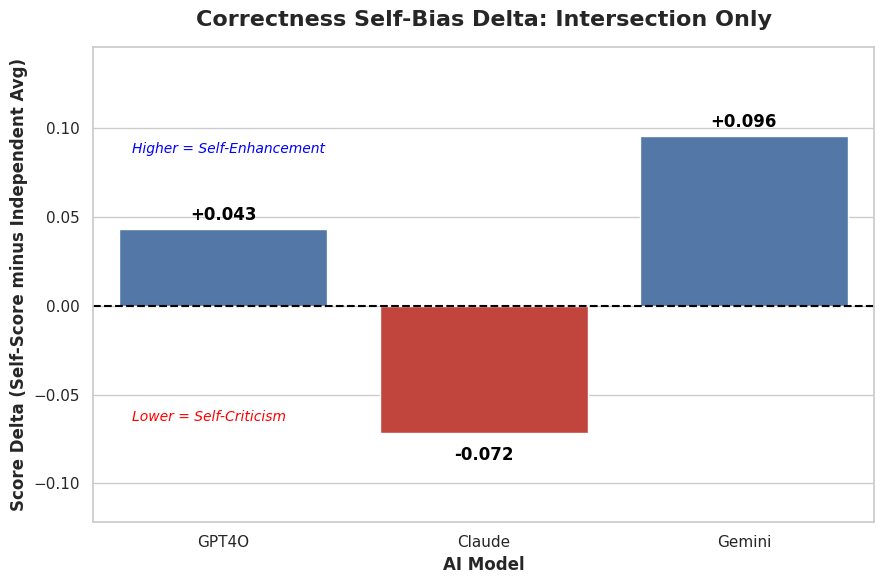

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Intersection Delta
# Mapping student model names to their exact judge string names
self_eval_mapping = {
    'gpt4o': 'gpt-4o',
    'claude': 'claude-sonnet-4-6',
    'gemini': 'gemini-2.5-pro'
}

# Ensure we are using the balanced intersection data
means = df_intersection.groupby(['student_model', 'judge_model'])['correctness_score'].mean().unstack()

delta_records = []

for student, self_judge in self_eval_mapping.items():
    # 1. Get the score the model gave itself
    self_score = means.loc[student, self_judge]

    # 2. Identify the independent judges
    independent_judges = [j for j in means.columns if j != self_judge]

    # 3. Calculate the average score from the independent judges
    independent_score = means.loc[student, independent_judges].mean()

    # 4. Calculate the Delta (Positive = Enhancement, Negative = Criticism)
    delta = self_score - independent_score

    delta_records.append({
        'Model': student.upper() if student == 'gpt4o' else student.capitalize(),
        'Self_Score': self_score,
        'Independent_Score': independent_score,
        'Delta': delta
    })

df_deltas = pd.DataFrame(delta_records)

print("="*60)
print("SELF-EVALUATION BIAS DELTAS (Intersection Data Only)")
print("="*60)
display(df_deltas.style.format({
    'Self_Score': '{:.3f}',
    'Independent_Score': '{:.3f}',
    'Delta': '{:+.3f}'
}).background_gradient(cmap='coolwarm', subset=['Delta']))

# 5. Visualize the Deltas
plt.figure(figsize=(9, 6))

# Color mapping: Positive = Self-Enhancement (Blue), Negative = Self-Criticism (Red)
colors = ['#d73027' if val < 0 else '#4575b4' for val in df_deltas['Delta']]

ax = sns.barplot(
    data=df_deltas,
    x='Model',
    y='Delta',
    palette=colors,
    hue='Model',
    legend=False
)

# Add a reference line at 0 (Perfect Neutrality)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Correctness Self-Bias Delta: Intersection Only', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Score Delta (Self-Score minus Independent Avg)', fontsize=12, fontweight='bold')
plt.xlabel('AI Model', fontsize=12, fontweight='bold')

# Add exact numbers near the bars
for i, v in enumerate(df_deltas['Delta']):
    y_pos = v + 0.005 if v > 0 else v - 0.015
    ax.text(i, y_pos, f"{v:+.3f}", ha='center', fontweight='bold', color='black')

# Add context text boxes
plt.text(-0.35, df_deltas['Delta'].max() * 0.9, 'Higher = Self-Enhancement', color='blue', fontsize=10, fontstyle='italic')
plt.text(-0.35, df_deltas['Delta'].min() * 0.9, 'Lower = Self-Criticism', color='red', fontsize=10, fontstyle='italic')

plt.ylim(df_deltas['Delta'].min() - 0.05, df_deltas['Delta'].max() + 0.05)
plt.tight_layout()
plt.show()

SELF-EVALUATION BIAS DELTAS (Full Dataset: 571 Evaluations)


,Model,Self_Score,Independent_Score,Delta
0,GPT4O,0.592,0.526,+0.065
1,Claude,0.685,0.713,-0.028
2,Gemini,0.653,0.607,+0.045


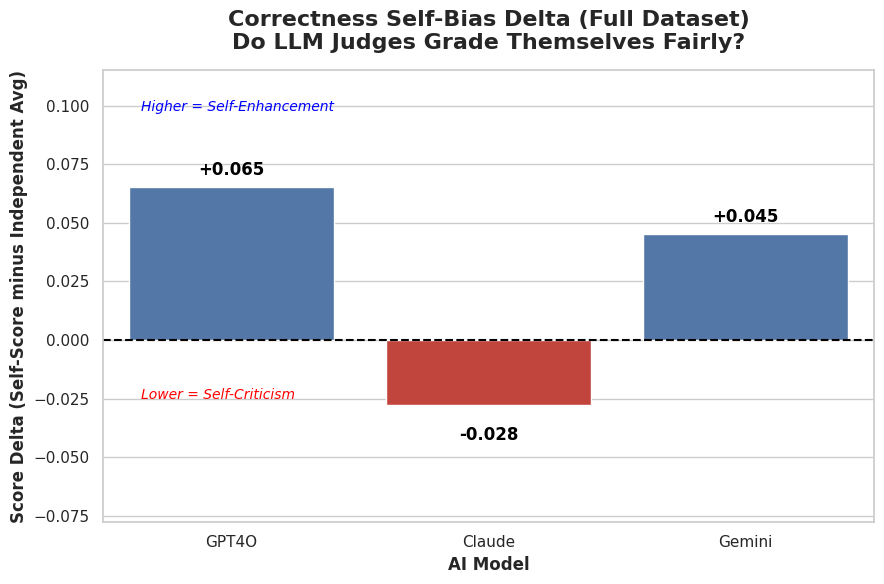

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Full Dataset Delta
# Mapping student model names to their exact judge string names
self_eval_mapping = {
    'gpt4o': 'gpt-4o',
    'claude': 'claude-sonnet-4-6',
    'gemini': 'gemini-2.5-pro'
}

# Calculate the mean scores on the FULL MASTER DATASET
means_full = df_master.groupby(['student_model', 'judge_model'])['correctness_score'].mean().unstack()

delta_records_full = []

for student, self_judge in self_eval_mapping.items():
    # 1. Grab the score the model gave itself
    self_score = means_full.loc[student, self_judge]

    # 2. Identify the independent judges (everyone else)
    independent_judges = [j for j in means_full.columns if j != self_judge]

    # 3. Calculate the average score from the independent judges
    independent_score = means_full.loc[student, independent_judges].mean()

    # 4. Calculate the Delta
    delta = self_score - independent_score

    delta_records_full.append({
        'Model': student.upper() if student == 'gpt4o' else student.capitalize(),
        'Self_Score': self_score,
        'Independent_Score': independent_score,
        'Delta': delta
    })

df_deltas_full = pd.DataFrame(delta_records_full)

print("="*60)
print("SELF-EVALUATION BIAS DELTAS (Full Dataset: 571 Evaluations)")
print("="*60)
display(df_deltas_full.style.format({
    'Self_Score': '{:.3f}',
    'Independent_Score': '{:.3f}',
    'Delta': '{:+.3f}'
}).background_gradient(cmap='coolwarm', subset=['Delta']))

# 5. Visualize the Deltas
plt.figure(figsize=(9, 6))

colors = ['#d73027' if val < 0 else '#4575b4' for val in df_deltas_full['Delta']]

ax = sns.barplot(
    data=df_deltas_full,
    x='Model',
    y='Delta',
    palette=colors,
    hue='Model',
    legend=False
)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Correctness Self-Bias Delta (Full Dataset)\nDo LLM Judges Grade Themselves Fairly?', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Score Delta (Self-Score minus Independent Avg)', fontsize=12, fontweight='bold')
plt.xlabel('AI Model', fontsize=12, fontweight='bold')

for i, v in enumerate(df_deltas_full['Delta']):
    y_pos = v + 0.005 if v > 0 else v - 0.015
    ax.text(i, y_pos, f"{v:+.3f}", ha='center', fontweight='bold', color='black')

plt.text(-0.35, df_deltas_full['Delta'].max() * 1.5, 'Higher = Self-Enhancement', color='blue', fontsize=10, fontstyle='italic')
plt.text(-0.35, df_deltas_full['Delta'].min() * 0.9, 'Lower = Self-Criticism', color='red', fontsize=10, fontstyle='italic')

plt.ylim(df_deltas_full['Delta'].min() - 0.05, df_deltas_full['Delta'].max() + 0.05)
plt.tight_layout()
plt.show()

The trends here are pretty similar, whether we're looking at the 28 intersection questions, or the full dataset. Claude is harsher on itself, whereas the other two models are more lenient.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

# Ensure mapping is correct
self_eval_mapping = {
    'gpt4o': 'gpt-4o',
    'claude': 'claude-sonnet-4-6',
    'gemini': 'gemini-2.5-pro'
}

# 1. Calculate Means for BOTH Metrics on the Intersection Data
means_correctness = df_intersection.groupby(['student_model', 'judge_model'])['correctness_score'].mean().unstack()
means_faithfulness = df_intersection.groupby(['student_model', 'judge_model'])['faithfulness_score'].mean().unstack()

delta_records = []

for student, self_judge in self_eval_mapping.items():
    independent_judges = [j for j in means_correctness.columns if j != self_judge]

    # Correctness Math
    self_c = means_correctness.loc[student, self_judge]
    ind_c = means_correctness.loc[student, independent_judges].mean()
    delta_c = self_c - ind_c

    # Faithfulness Math
    self_f = means_faithfulness.loc[student, self_judge]
    ind_f = means_faithfulness.loc[student, independent_judges].mean()
    delta_f = self_f - ind_f

    delta_records.append({
        'Model': student.upper() if student == 'gpt4o' else student.capitalize(),
        'Correctness_Delta': delta_c,
        'Faithfulness_Delta': delta_f
    })

df_metrics = pd.DataFrame(delta_records)

print("="*60)
print("SELF-EVALUATION BIAS DELTAS BY METRIC")
print("="*60)
display(df_metrics.style.format({
    'Correctness_Delta': '{:+.3f}',
    'Faithfulness_Delta': '{:+.3f}'
}).background_gradient(cmap='coolwarm'))

SELF-EVALUATION BIAS DELTAS BY METRIC


,Model,Correctness_Delta,Faithfulness_Delta
0,GPT4O,+0.043,+0.000
1,Claude,-0.072,-0.000
2,Gemini,+0.096,+0.024


But how statistically significant are these values? The p-value can give us some insight:

In [22]:
from scipy import stats

print("="*60)
print("STATISTICAL SIGNIFICANCE (Paired t-test)")
print("="*60)

for student, self_judge in self_eval_mapping.items():
    student_data = df_master[df_master['student_model'] == student]

    # Isolate paired scores for the exact same PMIDs
    pmids = student_data['pmid'].unique()
    rows = []

    for pmid in pmids:
        pmid_data = student_data[student_data['pmid'] == pmid]
        self_score_row = pmid_data[pmid_data['judge_model'] == self_judge]
        ind_score_rows = pmid_data[pmid_data['judge_model'] != self_judge]

        if not self_score_row.empty and not ind_score_rows.empty:
            self_val = self_score_row['correctness_score'].values[0]
            ind_val = ind_score_rows['correctness_score'].mean()
            rows.append({'self': self_val, 'independent': ind_val})

    df_pairs = pd.DataFrame(rows)

    if len(df_pairs) >= 2:
        t_stat, p_val = stats.ttest_rel(df_pairs['self'], df_pairs['independent'])
        sig_marker = "*** SIGNIFICANT ***" if p_val < 0.05 else "Not Significant"

        name = student.upper() if student == 'gpt4o' else student.capitalize()
        print(f"Model: {name}")
        print(f"  Sample Size: {len(df_pairs)} matched questions")
        print(f"  P-Value:     {p_val:.3f} ({sig_marker})\n")

STATISTICAL SIGNIFICANCE (Paired t-test)
Model: GPT4O
  Sample Size: 37 matched questions
  P-Value:     0.038 (*** SIGNIFICANT ***)

Model: Claude
  Sample Size: 34 matched questions
  P-Value:     0.912 (Not Significant)

Model: Gemini
  Sample Size: 19 matched questions
  P-Value:     0.620 (Not Significant)



This shows that gpt4o is the only statistically significant self-enhancer here, although our sample sizes are not matched, and quite small regardless.